# Pneumonia Classification with NNs
**Computer Vision | Assignment 2**

Goal: Maximize classification accuracy, precision and recall on the chest X-ray dataset (BACTERIAL / NORMAL / VIRAL).

## 1. Imports & Configuration

In [33]:
import time
import numpy as np
import tensorflow as tf
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling, RandomFlip, RandomRotation, RandomZoom, GlobalAveragePooling2D
from keras.optimizers import Adam
import os
from dotenv import load_dotenv
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# loads .env (paths to images)
load_dotenv()

TRAIN_DIR = os.getenv('TRAIN_DIR')
TEST_DIR  = os.getenv('TEST_DIR')

assert TRAIN_DIR and TEST_DIR, 'Set TRAIN_DIR and TEST_DIR in your .env file' # ensure env variables are loaded

# config
BATCH_SIZE   = 12
EPOCHS       = 8
IMG_HEIGHT   = 128
IMG_WIDTH    = 128
IMG_CHANNELS = 3
SEED         = 123

## 2. Load Datasets

In [2]:
# create training, validation and test datasets
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    validation_split=0.2,
    subset='both',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    labels='inferred',
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    seed=None,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    labels='inferred',
    shuffle=True
)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Classes:', class_names)
# print('Num classes:', num_classes)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Classes: ['BACTERIAL', 'NORMAL', 'VIRAL']


## 3. Dataset Distribution (Q2 - Is the dataset balanced?)

Training set distribution:
  BACTERIAL: 2596 images
  NORMAL: 1461 images
  VIRAL: 1363 images
  Total: 5420

Test set distribution:
  BACTERIAL: 184 images
  NORMAL: 122 images
  VIRAL: 132 images
  Total: 438


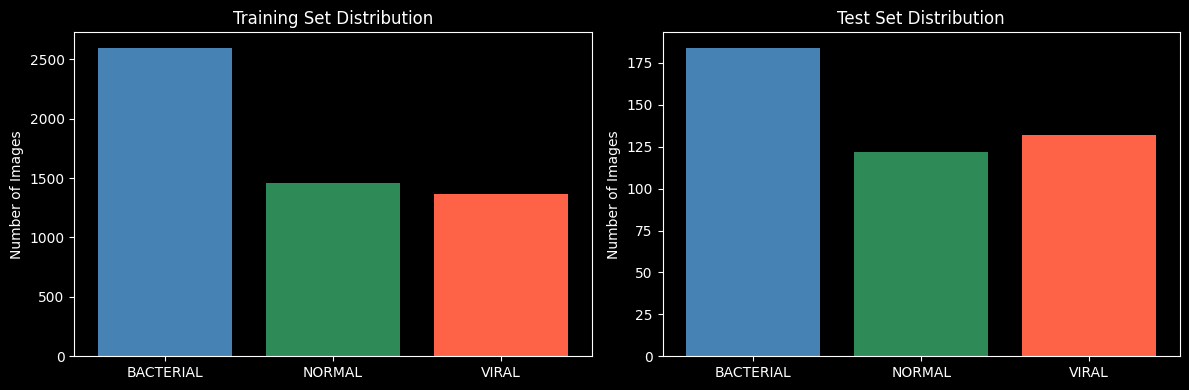

In [3]:
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print('Training set distribution:')
for cls, count in train_counts.items():
    print(f'  {cls}: {count} images')
print(f'  Total: {sum(train_counts.values())}')

print('\nTest set distribution:')
for cls, count in test_counts.items():
    print(f'  {cls}: {count} images')
print(f'  Total: {sum(test_counts.values())}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(train_counts.keys(), train_counts.values(), color=['steelblue', 'seagreen', 'tomato'])
axes[0].set_title('Training Set Distribution')
axes[0].set_ylabel('Number of Images')
axes[1].bar(test_counts.keys(), test_counts.values(), color=['steelblue', 'seagreen', 'tomato'])
axes[1].set_title('Test Set Distribution')
axes[1].set_ylabel('Number of Images')
plt.tight_layout()
plt.show()

## 4. Visualise Sample Images

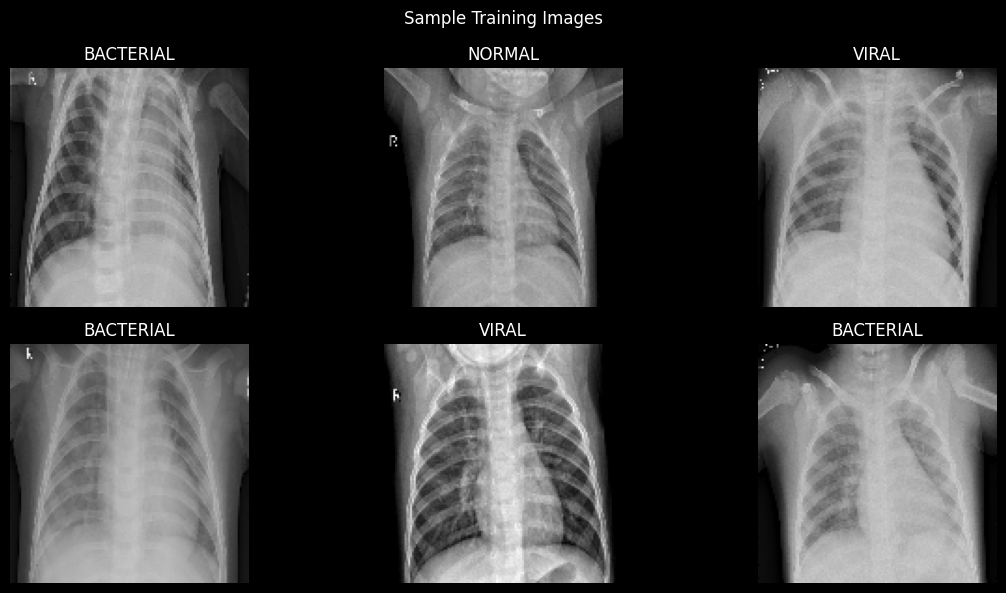

In [4]:
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(2):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i].numpy()])
        plt.axis('off')
plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

## 5. Baseline Model

In [5]:
model = tf.keras.models.Sequential([
    Rescaling(1.0 / 255),
    Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

# model.summary() # model summary visualization

/Users/akodini/college-projects/cv-assign2-ann/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 6. Train the Baseline Model (Q1 - How long does it take to train?)

In [6]:
save_callback = tf.keras.callbacks.ModelCheckpoint(
    'pneumonia_baseline.keras',
    save_freq='epoch',
    save_best_only=True
)

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    callbacks=[save_callback],
    epochs=EPOCHS
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)')

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.7184 - loss: 0.6533 - val_accuracy: 0.7553 - val_loss: 0.5835
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.7869 - loss: 0.5158 - val_accuracy: 0.7802 - val_loss: 0.5155
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.8024 - loss: 0.4773 - val_accuracy: 0.7747 - val_loss: 0.5409
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.8123 - loss: 0.4403 - val_accuracy: 0.7765 - val_loss: 0.5213
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.8233 - loss: 0.4044 - val_accuracy: 0.7645 - val_loss: 0.5459
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.8434 - loss: 0.3671 - val_accuracy: 0.7701 - val_loss: 0.5487
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.8586 - loss: 0.3266 - val_accuracy: 0.7572 - val_loss: 0.6181
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.8838 - loss: 0.2741 - val_accu

## 7. Evaluate on Test Set

In [7]:
score = model.evaluate(test_ds)
print(f'Test loss:     {score[0]:.4f}')
print(f'Test accuracy: {score[1]:.4f}')

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7483 - loss: 0.7066
Test loss:     0.7066
Test accuracy: 0.7483


## 8. Training Curves (Q3 - Is the network overfitting?)

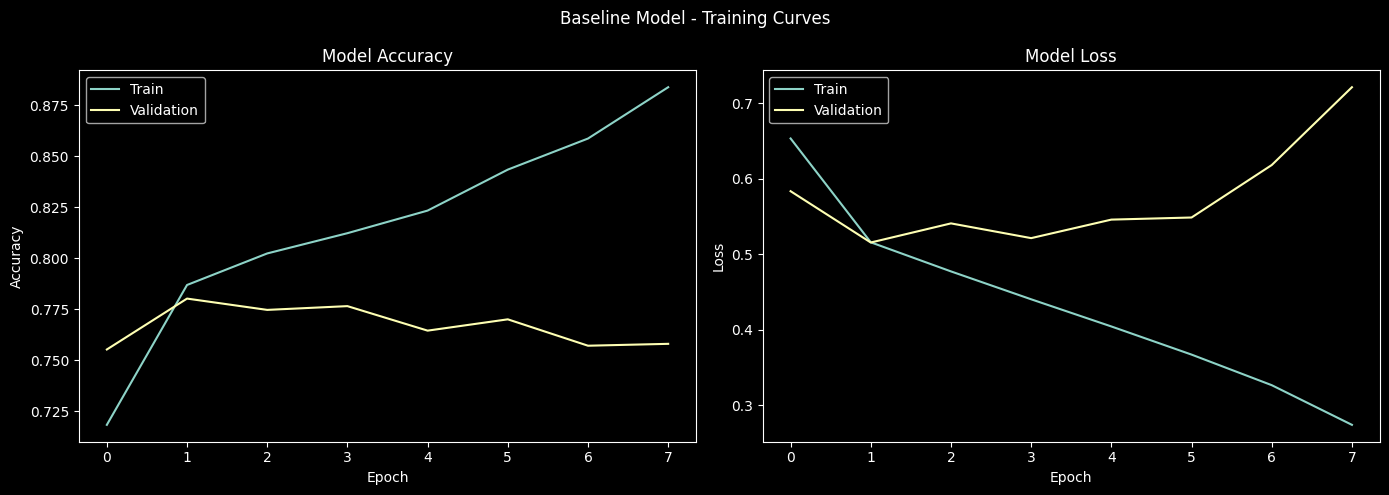

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Baseline Model - Training Curves')
plt.tight_layout()
plt.show()

## 9. Sample Predictions on Test Set

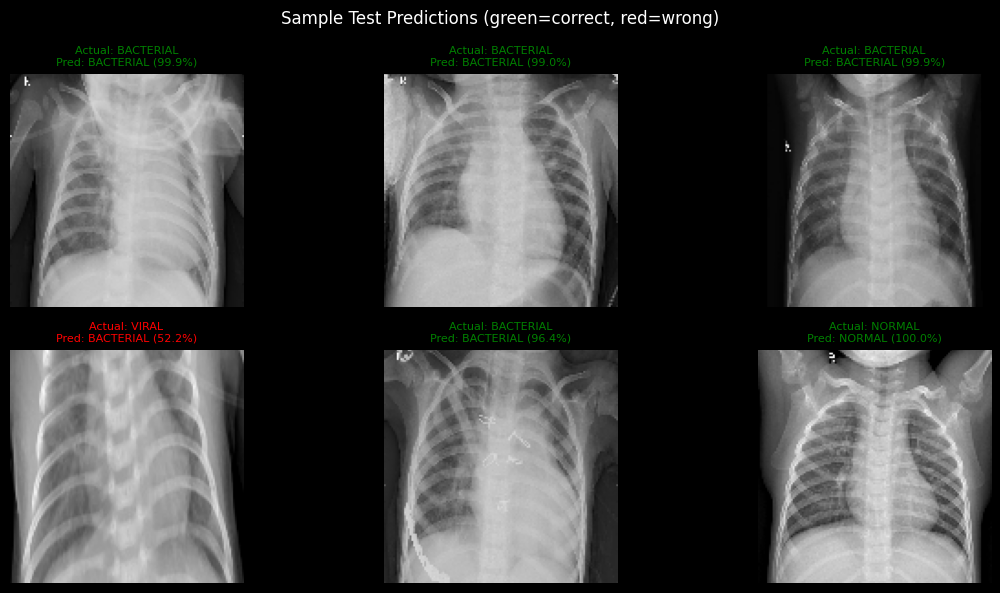

In [9]:
plt.figure(figsize=(12, 6))
for images, labels in test_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        prediction = model.predict(tf.expand_dims(images[i].numpy(), 0), verbose=0)
        actual = class_names[labels[i].numpy()]
        predicted = class_names[np.argmax(prediction)]
        confidence = 100 * np.max(prediction)
        color = 'green' if actual == predicted else 'red'
        plt.title(f'Actual: {actual}\nPred: {predicted} ({confidence:.1f}%)', color=color, fontsize=8)
        plt.axis('off')
plt.suptitle('Sample Test Predictions (green=correct, red=wrong)')
plt.tight_layout()
plt.show()

## 10. Per-Class Metrics (Q7 - Precision, Recall & F1)

Accuracy alone is misleading on imbalanced data. Per-class metrics show how well the model handles each class individually.

              precision    recall  f1-score   support

   BACTERIAL       0.69      0.83      0.75       184
      NORMAL       0.93      0.90      0.92       122
       VIRAL       0.66      0.50      0.57       131

    accuracy                           0.75       437
   macro avg       0.76      0.74      0.74       437
weighted avg       0.75      0.75      0.74       437



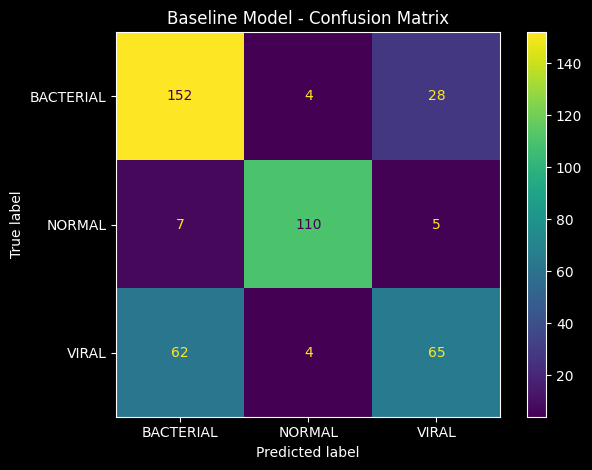

In [10]:
# collect all predictions and true labels from test set
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=class_names)
plt.title('Baseline Model - Confusion Matrix')
plt.tight_layout()
plt.show()

---
## 11. Improvements

In [46]:
base_model = tf.keras.applications.VGG16(
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    pooling='avg',
    weights='imagenet'
)
base_model.trainable = False  # Freeze pre-trained weights

improved_model = tf.keras.models.Sequential([
    # Data augmentation: randomly flip, rotate and zoom training images to reduce overfitting
    RandomFlip('horizontal'),
    RandomRotation(0.1),
    RandomZoom(0.1),
    tf.keras.layers.Lambda(tf.keras.applications.vgg16.preprocess_input),  # VGG16 expects BGR with mean subtraction
    base_model,
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

improved_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

In [47]:
from sklearn.utils.class_weight import compute_class_weight

# Extract all training labels to compute class weights
all_labels = np.concatenate([labels.numpy() for _, labels in train_ds])
weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
class_weights = dict(enumerate(weights))
print('Class weights:', class_weights)

Class weights: {0: np.float64(0.6925411276153969), 1: np.float64(1.240629470672389), 2: np.float64(1.3333333333333333)}


In [48]:
save_callback_imp = tf.keras.callbacks.ModelCheckpoint(
    'pneumonia_improved.keras',
    save_freq='epoch',
    save_best_only=True
)

start_time = time.time()

history_imp = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    callbacks=[save_callback_imp],
    class_weight=class_weights,
    epochs=5
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)')

Epoch 1/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 153s 420ms/step - accuracy: 0.5706 - loss: 2.3914 - val_accuracy: 0.6260 - val_loss: 1.4585
Epoch 2/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 160s 441ms/step - accuracy: 0.6488 - loss: 1.2584 - val_accuracy: 0.6851 - val_loss: 1.1283
Epoch 3/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 163s 450ms/step - accuracy: 0.6748 - loss: 1.0157 - val_accuracy: 0.7461 - val_loss: 0.8221
Epoch 4/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 177s 487ms/step - accuracy: 0.6942 - loss: 0.8466 - val_accuracy: 0.7184 - val_loss: 0.9184
Epoch 5/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 176s 485ms/step - accuracy: 0.6877 - loss: 0.8153 - val_accuracy: 0.7313 - val_loss: 0.7951

Training time: 827.3 seconds (13.8 minutes)


In [49]:
score_imp = improved_model.evaluate(test_ds)
print(f'Test loss:     {score_imp[0]:.4f}')
print(f'Test accuracy: {score_imp[1]:.4f}')

37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 385ms/step - accuracy: 0.7551 - loss: 0.6793
Test loss:     0.6793
Test accuracy: 0.7551


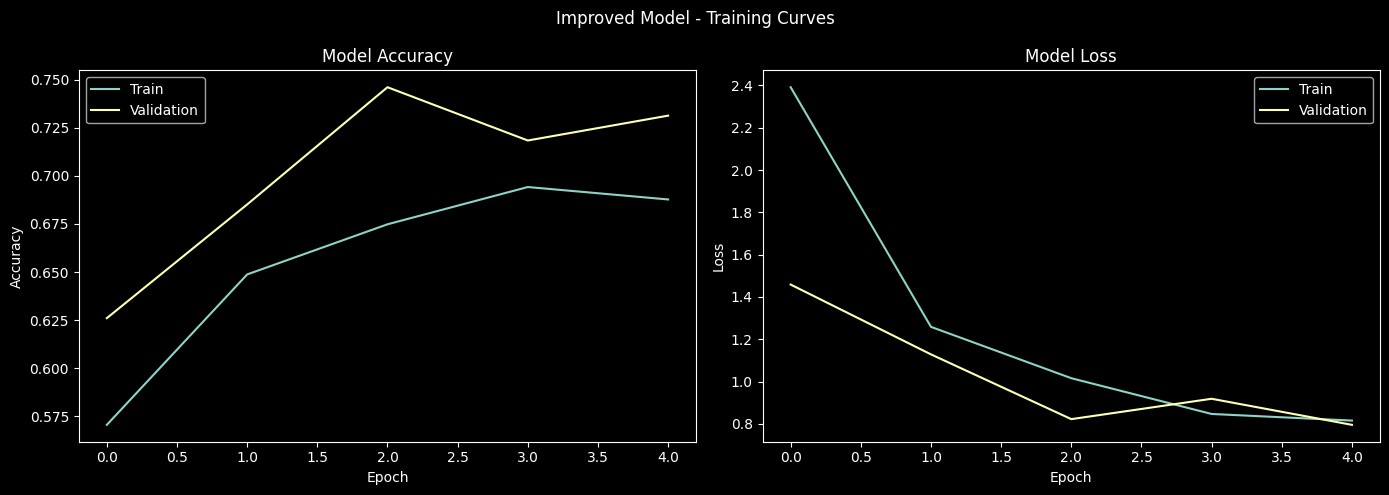

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_imp.history['accuracy'], label='Train')
axes[0].plot(history_imp.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_imp.history['loss'], label='Train')
axes[1].plot(history_imp.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Improved Model - Training Curves')
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

   BACTERIAL       0.72      0.80      0.76       184
      NORMAL       0.85      0.96      0.90       122
       VIRAL       0.69      0.50      0.58       131

    accuracy                           0.76       437
   macro avg       0.75      0.75      0.75       437
weighted avg       0.75      0.76      0.75       437



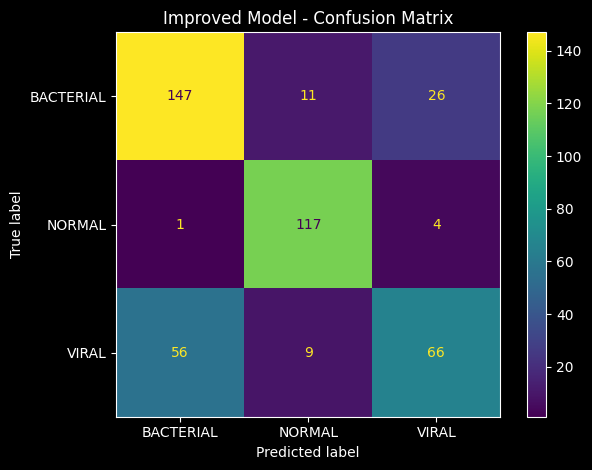

In [51]:
y_true_imp, y_pred_imp = [], []
for images, labels in test_ds:
    preds = improved_model.predict(images, verbose=0)
    y_pred_imp.extend(np.argmax(preds, axis=1))
    y_true_imp.extend(labels.numpy())

print(classification_report(y_true_imp, y_pred_imp, target_names=class_names))

ConfusionMatrixDisplay.from_predictions(y_true_imp, y_pred_imp, display_labels=class_names)
plt.title('Improved Model - Confusion Matrix')
plt.tight_layout()
plt.show()